# Where Does the State Live?
### Understanding LangGraph's State Machine

This notebook accompanies the blog post *Where Does the State Live?* on [axiom-ai.tech](https://axiom-ai.tech).

In this notebook, we look into LangGraph's state mechanics step by step: how a typed schema becomes channels, how the graph's edges become channels too, and how a run moves through steps.

1. **Channels over Classes:** How a typed schema compiles into discrete channel state machines (`LastValue` vs. `BinaryOperatorAggregate`).
2. **Edges as Channels:** Why flow and data share the same address space.
3. **The Superstep Barrier:** How LangGraph plans, executes, and applies state updates at step boundaries (`apply_writes`).
4. **Observable State History:** Stepping through a run, and running the same thread again.

Source references are to the LangGraph version printed below.

In [19]:
import os
import getpass
import json
import operator
from typing import TypedDict, Annotated, Literal
from importlib.metadata import version

import langgraph
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

# Pin and verify runtime version using standard metadata
print(f"LangGraph version: {version('langgraph')}")

LangGraph version: 1.2.8


## 1. Initializing the Model

We use OpenAI's `gpt-5.6-luna` (or any compatible chat model such as `gpt-4o-mini`). 

To keep this notebook self-contained and reproducible without external configuration files, you can add your API key below if it is not already exported in your environment.

In [20]:
# Set your OpenAI API key if not already present in the environment
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

# Target model configuration
MODEL_NAME = "gpt-5.6-luna"

llm = ChatOpenAI(
    model=MODEL_NAME,
    temperature=0,
)

# Smoke test: verify connectivity and model response
verification = llm.invoke([
    HumanMessage(content="Respond with the single word 'Connected' if you receive this message.")
])

print(f"Model [{MODEL_NAME}] status: {verification.content.strip()}")

Model [gpt-5.6-luna] status: Connected


## 2. The Data and the Functions

Before building the graph, we need a small, concrete problem for the model to work on. 

We will use an everyday device: a home power inverter. To keep things clean and self-contained, we define its manual right here as two simple Python dictionaries:
- `INVERTER_SPECS`: general specifications, rated wattage, and operating modes.
- `INVERTER_SUPPORT`: common warning indicators, beeps, and troubleshooting steps.

We then write two simple Python functions to look up information from these dictionaries. Notice that these are just standard functions—we are not using any decorators, schemas, or prebuilt library tools.

In [21]:
# Reference data for a home power inverter

INVERTER_SPECS = {
    "model": "PureSine 900VA",
    "rated_capacity": "720 Watts",
    "battery_support": "Single 12V tubular or flat-plate battery (100Ah - 200Ah)",
    "eco_mode": "Voltage window 100V - 290V. Saves energy, but switchover time is ~35ms, which may cause desktop computers to restart.",
    "ups_mode": "Voltage window 180V - 260V. Fast switchover time under 10ms, designed to keep computers and sensitive electronics running.",
}

INVERTER_SUPPORT = {
    "overload_alarm": "Continuous buzzer sound and red Overload LED. The connected load exceeds 720W. Disconnect heavy appliances and press the reset switch on the rear panel.",
    "low_water_indicator": "Low Water LED blinking with intermittent beeps. Electrolyte level in the battery has fallen. Top up with distilled water to the green float mark. Never use tap water.",
    "battery_low": "Red battery LED blinking rapidly. Battery charge has dropped below 10.5V. Allow the unit to recharge from the mains for at least 6 to 8 hours.",
}


def lookup_specs(topic: str) -> str:
    """Looks up technical specifications and operating modes for the inverter."""
    query = topic.lower().strip()
    for key, description in INVERTER_SPECS.items():
        if key in query or query in key:
            return f"Specification ({key}): {description}"
    return "No matching specification found. Available topics: model, rated_capacity, battery_support, eco_mode, ups_mode."


def lookup_support(symptom: str) -> str:
    """Looks up troubleshooting steps and warning indicators for the inverter."""
    query = symptom.lower().strip()
    for key, description in INVERTER_SUPPORT.items():
        if key in query or query in key:
            return f"Troubleshooting ({key}): {description}"
    return "No matching troubleshooting entry found. Available topics: overload_alarm, low_water_indicator, battery_low."


# Quick check to see what the functions return
print(lookup_specs("eco_mode"))
print(lookup_support("overload_alarm"))

Specification (eco_mode): Voltage window 100V - 290V. Saves energy, but switchover time is ~35ms, which may cause desktop computers to restart.
Troubleshooting (overload_alarm): Continuous buzzer sound and red Overload LED. The connected load exceeds 720W. Disconnect heavy appliances and press the reset switch on the rear panel.


## 3. Defining State and the Nodes

Now we build the pieces of the graph.

First, we define our state schema using a standard `TypedDict`. In LangGraph, each field in this schema becomes a **channel**:
- `user_query`, `next_action`, `search_query`, and `final_answer`: these have no special annotations, so LangGraph assigns them a `LastValue` channel. Every time a node writes to them, the old value is overwritten.
- `findings`: annotated with `operator.add`. This tells LangGraph to use a `BinaryOperatorAggregate` channel. Whenever a node returns a list of notes, they are appended to the existing list rather than replacing it.

Next, we write our three nodes as plain Python functions:
1. `analyze_and_decide`: the reasoning node. It reads the current query and any accumulated notes, and decides whether it needs to check specifications, check troubleshooting support, or write the final answer.
2. `specs_node`: calls `lookup_specs` and appends what it found to `findings`.
3. `support_node`: calls `lookup_support` and appends what it found to `findings`.

In [22]:
from pydantic import BaseModel, Field


# 1. A small structured schema to guide the model's decision
class AgentDecision(BaseModel):
    action: Literal["check_specs", "check_support", "respond"] = Field(
        description="The next step: 'check_specs' for technical specs, 'check_support' for troubleshooting faults, or 'respond' when you have enough information."
    )
    search_query: str = Field(
        default="",
        description="The topic or symptom to look up (e.g., 'overload_alarm' or 'rated_capacity')."
    )
    answer: str = Field(
        default="",
        description="The final helpful answer to the user if action is 'respond'."
    )


# Configure the model to return structured decisions
decision_model = llm.with_structured_output(AgentDecision)


# 2. State Schema
class InverterState(TypedDict):
    user_query: str
    next_action: str
    search_query: str
    findings: Annotated[list[str], operator.add]
    final_answer: str


# 3. Node Functions

def analyze_and_decide(state: InverterState) -> dict:
    """The reasoning step: looks at the user query and accumulated findings to pick the next step."""
    accumulated_notes = "\n".join(state.get("findings", [])) if state.get("findings") else "No notes gathered yet."
    
    prompt = (
        f"User Query: {state['user_query']}\n\n"
        f"Reference notes collected so far:\n{accumulated_notes}\n\n"
        f"Decide your next action: check specifications, check troubleshooting support, or formulate your final response."
    )
    
    decision: AgentDecision = decision_model.invoke([
        SystemMessage(content=(
            "You are a helpful home appliance diagnostic assistant. "
            "Gather factual information from the manual before offering advice. "
            "Be concise and clear."
        )),
        HumanMessage(content=prompt)
    ])
    
    if decision.action == "respond":
        return {
            "next_action": "respond",
            "final_answer": decision.answer
        }
    
    return {
        "next_action": decision.action,
        "search_query": decision.search_query
    }


def specs_node(state: InverterState) -> dict:
    """Action step: reads inverter specifications and returns an update."""
    query = state.get("search_query", "")
    result = lookup_specs(query)
    return {"findings": [result]}


def support_node(state: InverterState) -> dict:
    """Action step: reads troubleshooting guidelines and returns an update."""
    query = state.get("search_query", "")
    result = lookup_support(query)
    return {"findings": [result]}

## 4. Assembling and Compiling the Graph

Now we connect the nodes into an executable graph using `StateGraph`.

The flow follows a simple decision loop:
1. The graph starts at `analyze_and_decide`.
2. A conditional edge evaluates `state["next_action"]`:
   - If the model chose `"check_specs"`, it routes to `specs_node`.
   - If the model chose `"check_support"`, it routes to `support_node`.
   - If the model chose `"respond"`, it routes to `END`.
3. When `specs_node` or `support_node` completes, a static edge routes back to `analyze_and_decide`. This completes the cycle: the model receives the updated notes and decides whether it needs more information or is ready to answer.

We compile the graph with `MemorySaver`. This in-memory checkpointer preserves a snapshot of all channels at every step, which will let us inspect the superstep history afterward.

In [23]:
# 1. Routing function for the conditional edge
def route_decision(state: InverterState) -> str:
    """Inspects next_action to determine the destination node."""
    action = state.get("next_action")
    if action == "check_specs":
        return "specs_node"
    elif action == "check_support":
        return "support_node"
    return END


# 2. Build the StateGraph
workflow = StateGraph(InverterState)

# Register the three nodes
workflow.add_node("analyze_and_decide", analyze_and_decide)
workflow.add_node("specs_node", specs_node)
workflow.add_node("support_node", support_node)

# Set the entry point
workflow.add_edge(START, "analyze_and_decide")

# Add conditional branching from the reasoning node
workflow.add_conditional_edges(
    "analyze_and_decide",
    route_decision,
    {
        "specs_node": "specs_node",
        "support_node": "support_node",
        END: END,
    }
)

# Complete the loop: both knowledge nodes return to the reasoning node
workflow.add_edge("specs_node", "analyze_and_decide")
workflow.add_edge("support_node", "analyze_and_decide")

# 3. Compile with an in-memory checkpointer
checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)

print("Graph assembled and compiled successfully.")

Graph assembled and compiled successfully.


### Inspecting the Compiled Graph

The compiled graph is a `Pregel` object, and it exposes its channels and nodes directly. From `attach_node` and `attach_edge` in `state.py`, we expect three things: each state key as a channel; one `branch:to:{node}` trigger channel per node; and each node subscribed to its own trigger. A static edge should appear as a write to the target's trigger channel.

In [24]:
from langgraph.pregel._write import ChannelWriteEntry

print(f"{'Channel':34} Type")
for name, channel in app.channels.items():
    print(f"{name:34} {type(channel).__name__}")

print(f"\n{'Node':22} Triggered by")
for name, node in app.nodes.items():
    print(f"{name:22} {node.triggers}")

# The static edge specs_node -> analyze_and_decide, as it exists after compilation
edge_writes = [
    entry.channel
    for writer in app.nodes["specs_node"].writers
    for entry in getattr(writer, "writes", [])
    if isinstance(entry, ChannelWriteEntry)
]
print(f"\nspecs_node writes to: {edge_writes}")

Channel                            Type
user_query                         LastValue
next_action                        LastValue
search_query                       LastValue
findings                           BinaryOperatorAggregate
final_answer                       LastValue
__start__                          EphemeralValue
__pregel_tasks                     Topic
branch:to:analyze_and_decide       EphemeralValue
branch:to:specs_node               EphemeralValue
branch:to:support_node             EphemeralValue

Node                   Triggered by
__start__              ['__start__']
analyze_and_decide     ['branch:to:analyze_and_decide']
specs_node             ['branch:to:specs_node']
support_node           ['branch:to:support_node']

specs_node writes to: ['branch:to:analyze_and_decide']


In [25]:
# The default bound on steps per run; private module, so guarded
try:
    from langgraph._internal._config import DEFAULT_RECURSION_LIMIT
    print(f"Default recursion_limit: {DEFAULT_RECURSION_LIMIT}")
except ImportError:
    print("DEFAULT_RECURSION_LIMIT not found at this path in this version.")

Default recursion_limit: 10007


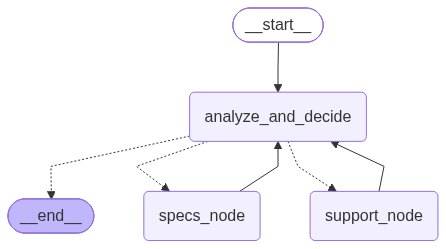

In [26]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

## 5. Running the Agent

Now we test the graph with our domestic query:

> *"The overload buzzer went off this morning. What does that mean, and what is the maximum wattage load this model can actually handle?"*

To answer this completely, the agent cannot guess; it needs facts from both sides of the manual:
1. What the buzzer signifies (from `INVERTER_SUPPORT`).
2. The exact rated capacity (from `INVERTER_SPECS`).

We provide a `thread_id` inside `config["configurable"]`. LangGraph uses this key to track and save the checkpoint history for this specific conversation.
The model is called with `temperature=0`, but the run is not guaranteed to be deterministic. Your run may take a different number of steps, or look up different topics, than the one shown here.

In [27]:
# Checkpointer thread identifier
config = {"configurable": {"thread_id": "inverter-run-01"}}

# The user query touching both troubleshooting and specifications
user_query = (
    "The overload buzzer went off this morning. "
    "What does that mean, and what is the maximum wattage load this model can actually handle?"
)

# Run the graph
result = app.invoke(
    {"user_query": user_query},
    config=config
)

# Display the outcome
print("--- Final Response ---")
print(result.get("final_answer"))

print("\n--- Accumulated Notes in State (findings channel) ---")
for i, note in enumerate(result.get("findings", []), 1):
    print(f"[{i}] {note}")

--- Final Response ---
The continuous overload buzzer and red Overload LED mean the connected appliances exceeded the unit’s rated load. For the PureSine 900VA, the maximum supported load is 720 watts. Disconnect high-power appliances, then press the reset switch on the rear panel.

--- Accumulated Notes in State (findings channel) ---
[1] Specification (model): PureSine 900VA
[2] No matching specification found. Available topics: model, rated_capacity, battery_support, eco_mode, ups_mode.
[3] Specification (rated_capacity): 720 Watts
[4] Troubleshooting (overload_alarm): Continuous buzzer sound and red Overload LED. The connected load exceeds 720W. Disconnect heavy appliances and press the reset switch on the rear panel.


Notice the misses in `findings`. The first lookups use natural language, which the simple matcher doesn't recognise, so the tool replies with its list of available topics. The next lookups use those exact keys. The tool's own reply taught the model the vocabulary. The `findings` channel kept every note, misses included: `operator.add` folds every update in, without judging it.

## 6. Inspecting the State History

Because we compiled the graph with `MemorySaver`, LangGraph recorded an immutable snapshot of all state channels at every step boundary.

We can read this history using `app.get_state_history(config)`. 

By default, `get_state_history` yields snapshots in reverse chronological order (newest first). Below, we reverse the list to step through the execution from the very beginning.

Note:
1. Step −1 is the input checkpoint (`source: input`), and step 0 runs `__start__`, which copies the input into the state channels and triggers the first node.
2. `next_action` and `search_query` change only when a node writes them; otherwise they hold their last value (`LastValue`).
3. `findings` grows with each lookup (`BinaryOperatorAggregate`).

In [28]:
# Retrieve the full checkpoint history for our run
history = list(app.get_state_history(config))

print(f"Total checkpoints recorded: {len(history)}\n")

# Print each superstep in chronological order
for snapshot in reversed(history):
    step = snapshot.metadata.get("step", "N/A")
    source = snapshot.metadata.get("source", "N/A")
    next_nodes = snapshot.next if snapshot.next else ("(end)",)
    
    action = snapshot.values.get("next_action", "none")
    search_topic = snapshot.values.get("search_query", "none")
    findings_count = len(snapshot.values.get("findings", []))
    has_answer = bool(snapshot.values.get("final_answer"))
    
    print(f"--- Step {step} (source: {source}) ---")
    print(f"  Next node scheduled : {next_nodes}")
    print(f"  State ['next_action']: {action}")
    print(f"  State ['search_query']: {search_topic}")
    print(f"  Accumulated notes   : {findings_count}")
    print(f"  Final answer ready  : {has_answer}")
    print()

Total checkpoints recorded: 11

--- Step -1 (source: input) ---
  Next node scheduled : ('__start__',)
  State ['next_action']: none
  State ['search_query']: none
  Accumulated notes   : 0
  Final answer ready  : False

--- Step 0 (source: loop) ---
  Next node scheduled : ('analyze_and_decide',)
  State ['next_action']: none
  State ['search_query']: none
  Accumulated notes   : 0
  Final answer ready  : False

--- Step 1 (source: loop) ---
  Next node scheduled : ('specs_node',)
  State ['next_action']: check_specs
  State ['search_query']: overload buzzer meaning and maximum wattage load for this model
  Accumulated notes   : 0
  Final answer ready  : False

--- Step 2 (source: loop) ---
  Next node scheduled : ('analyze_and_decide',)
  State ['next_action']: check_specs
  State ['search_query']: overload buzzer meaning and maximum wattage load for this model
  Accumulated notes   : 1
  Final answer ready  : False

--- Step 3 (source: loop) ---
  Next node scheduled : ('specs_node'

## 6b. Running the Same Thread Again

The checkpointer saves the channels under the `thread_id`. If we invoke the graph again with the same `config`, the run doesn't start from empty state. It starts from the last checkpoint of this thread. The new input writes only `user_query`; `findings` keeps every note from the first run, and step numbering continues from where it stopped.

In [29]:
before = len(list(app.get_state_history(config)))

second = app.invoke({"user_query": user_query}, config=config)

history_after = list(app.get_state_history(config))
new_snapshots = history_after[: len(history_after) - before]  # newest first

print(f"New checkpoints from the second run: {len(new_snapshots)}\n")
for snapshot in reversed(new_snapshots):
    step = snapshot.metadata.get("step")
    source = snapshot.metadata.get("source")
    next_nodes = snapshot.next if snapshot.next else ("(end)",)
    findings_count = len(snapshot.values.get("findings", []))
    print(f"Step {step:>3} ({source:5})  next: {next_nodes}  notes: {findings_count}")

print("\n--- Final Response (second run) ---")
print(second.get("final_answer"))

New checkpoints from the second run: 3

Step  10 (input)  next: ('__start__',)  notes: 4
Step  11 (loop )  next: ('analyze_and_decide',)  notes: 4
Step  12 (loop )  next: ('(end)',)  notes: 4

--- Final Response (second run) ---
The continuous overload buzzer and red Overload LED mean the connected equipment is drawing more than the unit’s rated limit. For the PureSine 900VA, the maximum rated load is 720 watts. Disconnect one or more high-power appliances, then press the reset switch on the rear panel.


## 7. Testing Channel Behaviors

Now that we have seen the graph work under normal conditions, let's verify what the source code in `state.py` predicts.

### Experiment 1: Removing the Reducer
In our original `InverterState`, we declared:
`findings: Annotated[list[str], operator.add]`

When `StateGraph(InverterState)` was constructed, LangGraph read that type hint, found `operator.add`, and created a `BinaryOperatorAggregate` channel.

What happens if we remove the annotation and write a plain list:
`findings: list[str]`?

According to `_get_channel` in `state.py`, any un-annotated field falls back to `LastValue`. Below, we create a simple two-node sequence where each node returns a note.

In [30]:
# A state schema where 'findings' has no reducer annotation
class UnannotatedState(TypedDict):
    findings: list[str]


def note_step_a(state: UnannotatedState) -> dict:
    return {"findings": ["Note A: Battery is rated 12V 150Ah."]}


def note_step_b(state: UnannotatedState) -> dict:
    return {"findings": ["Note B: Water topped up with distilled water."]}


# Build a simple two-step linear graph
test_flow = StateGraph(UnannotatedState)
test_flow.add_node("step_a", note_step_a)
test_flow.add_node("step_b", note_step_b)

test_flow.add_edge(START, "step_a")
test_flow.add_edge("step_a", "step_b")
test_flow.add_edge("step_b", END)

test_app = test_flow.compile()

# Run the test
output = test_app.invoke({"findings": []})

print("Result in 'findings' channel:")
print(output["findings"])

Result in 'findings' channel:
['Note B: Water topped up with distilled water.']


### Experiment 2: Concurrent Writes to a LastValue Channel

In `langgraph/channels/last_value.py`, the `update` method enforces a strict rule:

```python
if len(values) != 1:
    msg = create_error_message(
        message=f"At key '{self.key}': Can receive only one value per step. Use an Annotated key to handle multiple values.",
        error_code=ErrorCode.INVALID_CONCURRENT_GRAPH_UPDATE,
    )
    raise InvalidUpdateError(msg)
```

Below, two workers run in the same step and both write to `status`. Each writes to its own buffer, so neither fails. The error is raised afterwards, when `apply_writes` passes both values to the channel's `update`.

In [31]:
from langgraph.errors import InvalidUpdateError


# State with an un-annotated string channel (LastValue)
class ParallelState(TypedDict):
    status: str


def parallel_worker_one(state: ParallelState) -> dict:
    print("worker_one ran")
    return {"status": "Worker One completed"}


def parallel_worker_two(state: ParallelState) -> dict:
    print("worker_two ran")
    return {"status": "Worker Two completed"}


# Fan out from START to both workers in parallel
parallel_flow = StateGraph(ParallelState)
parallel_flow.add_node("worker_one", parallel_worker_one)
parallel_flow.add_node("worker_two", parallel_worker_two)

parallel_flow.add_edge(START, "worker_one")
parallel_flow.add_edge(START, "worker_two")
parallel_flow.add_edge("worker_one", END)
parallel_flow.add_edge("worker_two", END)

parallel_app = parallel_flow.compile()

# Execute and catch the collision at the update barrier
try:
    parallel_app.invoke({"status": "Initial state"})
except InvalidUpdateError as err:
    print("Caught expected InvalidUpdateError from last_value.py:")
    print(err)

worker_one ran
worker_two ran
Caught expected InvalidUpdateError from last_value.py:
At key 'status': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


### Experiment 3: The Same Writes, with a Reducer

The error message suggests the fix: an annotated key. With a reducer, the channel folds both values in one update. `apply_writes` sorts tasks by path before applying their writes, so the order of the result should not depend on which worker finished first.

In [32]:
class ParallelReducedState(TypedDict):
    status: Annotated[list[str], operator.add]


def reduced_worker_one(state: ParallelReducedState) -> dict:
    return {"status": ["Worker One completed"]}


def reduced_worker_two(state: ParallelReducedState) -> dict:
    return {"status": ["Worker Two completed"]}


reduced_flow = StateGraph(ParallelReducedState)
reduced_flow.add_node("worker_one", reduced_worker_one)
reduced_flow.add_node("worker_two", reduced_worker_two)
reduced_flow.add_edge(START, "worker_one")
reduced_flow.add_edge(START, "worker_two")
reduced_flow.add_edge("worker_one", END)
reduced_flow.add_edge("worker_two", END)

reduced_app = reduced_flow.compile()
print(reduced_app.invoke({"status": []})["status"])

['Worker One completed', 'Worker Two completed']


## 8. Summary and Key Takeaways

Through this notebook, we opened up LangGraph's runtime to observe where state lives and how it moves:

1. **State Is a Collection of Channels:**  
   At runtime, state is neither a raw dictionary nor a Pydantic class instance. It is a set of discrete channel state machines. The type annotations in our schema simply instruct LangGraph which channel type to assign to each key.
2. **Channel Types Enforce Concurrency Rules:**  
   - An un-annotated key compiles to `LastValue`. It accepts at most one update per superstep and raises `InvalidUpdateError` if multiple nodes write to it simultaneously.
   - An annotated key like `Annotated[list, operator.add]` compiles to `BinaryOperatorAggregate`, safely folding multiple updates using the declared operator.
3. **Flow and State Share the Same Address Space:**  
   Edges do not exist as independent runtime entities. Each node is triggered by its own `branch:to:{node}` channel, and an edge, static or conditional, is a write to that channel. In LangGraph, flow moves through the same channel mechanism that holds the data.
4. **The Superstep Barrier:**  
   Within a step, every task reads the same snapshot and writes to its own buffer. Writes are applied to the channels only at the end of the step, in `apply_writes`, and a checkpoint is saved after it.
5. **State Belongs to the Thread:**  
   With a checkpointer, the channels are saved under a `thread_id`. Invoking the same thread again continues from its last checkpoint, with step numbering carried forward.

---

### What Comes Next

In LangGraph, state and flow live together in channels reconciled at a superstep barrier. 

Is this the only way to represent an agent? 

In the next post of this series, we will take this exact same home inverter scenario and implement it in another framework, exploring how event-driven runtimes and local loops answer the same fundamental question: **Where does the state live?**

---
*For the complete architectural walkthrough and source code references, read the companion blog on [axiom-ai.tech](https://axiom-ai.tech).*